
To construct the training dataset, I first used the provided image-generation network to generate a sufficiently large set of synthetic brain images. Since these images will be reused multiple times during model training and experimentation, I saved the generated outputs to a dedicated folder in my Google Drive. This ensures efficient reuse without repeatedly running the generative model.

Using the generate function supplied with the trained model, I experimented with different input parameters to obtain images that are both visually coherent and diverse enough for downstream training. I adjusted the generation settings until the produced samples showed clear brain structures without excessive artefacts, ensuring they would be suitable for the reconstruction task.

After generating the dataset, I loaded the saved images and displayed ten randomly selected samples to visually verify their quality and consistency.

In addition, I loaded the corrupted images provided in test_set.npy from the repository. I then displayed ten examples from this corrupted dataset to better understand the nature of the degradation and to compare them visually with the clean generated images. This comparison helps inform the design and evaluation of the reconstruction model.



## load data

In [1]:
import os
import sys

In [2]:
# Pull and install necessary files
from google.colab import drive
drive.mount('/content/drive')

# INSTRUCTIONS:
# Open in a BROWSER https://drive.google.com/file/d/1I8Ry7Z_QqnlARwOuDgN4NPCd-GcLw1OC/view?usp=drive_link
# Download the file cw1_files.zip
# Go to https://drive.google.com/ and log in with the account you will be using for this coursework
# In the folder 'My Drive' upload cw1_files.zip (DO NOT UNZIP THE FILE)
# Run the following:

!unzip /content/drive/MyDrive/cw1_files.zip -d ./
!chmod +x run.sh
!bash ./run.sh
sys.path.append('/content/ese-invldm')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/cw1_files.zip
  inflating: ./files/config_training.yml  
  inflating: ./run.sh                
  inflating: ./ese-invldm/setup.py   
  inflating: ./files/default_config.yml  
  inflating: ./ese-invldm/ese_invldm/ese_invldm.py  
  inflating: ./ese-invldm/ese_invldm/__init__.py  
  inflating: ./files/autoencoder/autoencoder_ckpt_latest.pth  
  inflating: ./files/diffusion/diffusion_ckpt_latest.pth  
Cloning the repository from https://github.com/dpelacani/InverseLDM.git...
Cloning into 'InverseLDM'...
remote: Enumerating objects: 1331, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 1331 (delta 167), reused 182 (delta 100), pack-reused 1070 (from 1)
Receiving objects: 100% (1331/1331), 467.16 KiB | 19.46 MiB/s, done.
Resolving deltas: 100% (875/875), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.1 M

In [76]:
from ese_invldm import generate

"""
Generates samples using a diffusion-based generative model.

This function leverages a pre-configured diffusion model to produce synthetic samples.
The sampling process supports adjustable parameters for total samples, inference steps, and batch size.
A scheduler and temperature can also be configured to control the sampling behaviour.

Parameters:
    num_samples (int):
        Total number of samples to generate.
    num_inference_steps (int):
        Number of diffusion inference steps.
        The minimum number of steps is 1, but we recommend exploring the range from 10 to 50.
        Please note that more steps will increase quality but also the computational cost. Be careful not
        to burn through your credits by using a very large number of steps!
    batch_size (int):
        Number of samples to process in each batch during sampling.
    scheduler (str, optional):
        Sampling scheduler to use (e.g., "ddim", "ddpm"). You can quickly test which one provides the most appropriate results
        for this task.
    temperature (float, optional):
        Sampling temperature to control randomness, given as a number between 0 and 1. Higher values produce more diverse outputs.
    seed (int, optional):
        Random seed for reproducibility. Defaults to 42.

Returns:
    list:
        A list containing the batches of generated samples, where each sample
        corresponds to a single data instance produced by the diffusion model.

"""

samples = generate(
    num_samples=3200,
    num_inference_steps=20,#
    batch_size=64,
    scheduler="ddim",
    temperature=0.8,
    seed=86
)

/content/InverseLDM/invldm/runners/base_runner.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_states = torch.load(path)


Batch 0


100%|██████████| 20/20 [00:02<00:00,  8.09it/s]


Batch 1


100%|██████████| 20/20 [00:02<00:00,  8.20it/s]


...

100%|██████████| 20/20 [00:02<00:00,  8.20it/s]


Batch 48


100%|██████████| 20/20 [00:02<00:00,  8.19it/s]


Batch 49


100%|██████████| 20/20 [00:02<00:00,  8.19it/s]


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Save the image to google drive:**



In [77]:
import numpy as np
generated_samples = np.array([sample.cpu().numpy() for sample in samples])

np.save("/content/drive/My Drive/generated_sample.npy", generated_samples)



## Show the first generated images:

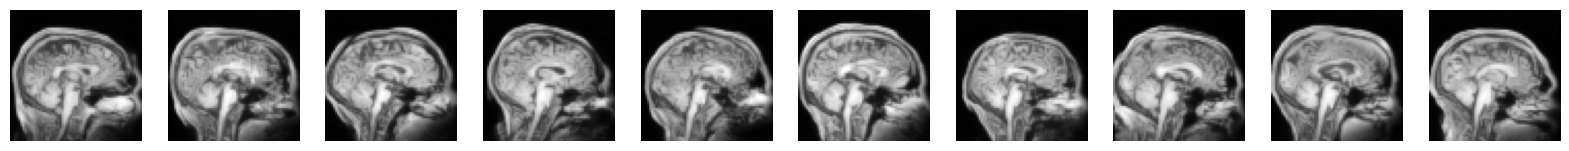

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_samples(samples, num_images=10):
    """
    Plots the first image from the first `num_images` batches in the samples list.

    Parameters:
        samples (list of arrays or tensors): A list where each item is a batch of images.
        num_images (int): Number of batches to display the first image from.

    Assumes that each batch contains images in a format suitable for direct plotting (e.g., tensors).
    """
    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))  # Create a row of subplots

    for i, ax in enumerate(axes):
        if i >= len(samples):
            break
        img = samples[i][0]  # Get the first image from the i-th batch

        # Convert to numpy if it's a Tensor
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()  # Ensure it's moved to CPU before converting

        # Rescale if the values are from -1 to 1
        if img.min() < 0:
            img = (img + 1) / 2  # Rescale to [0, 1]

        # Remove channel dimension if it's grayscale
        if img.shape[0] == 1:  # CHW format and 1 channel
            img = img.squeeze(0)  # Remove channel dimension

        # Display the image
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')  # Turn off axis

    plt.show()

# Assuming `samples` is a list where each element is a batch of images as tensors with shape (batch_size, channels, height, width)
plot_samples(samples, num_images=10)


I tried number of samples from 100 to 300 to 640 to 6400
try batch size from 10 to 30 to 64,
temperature from 0.6 to 0.7 to 0.9,
try number of inference steps from 10 to 20 to 30
adapt DDIM and DDPM. I can see that the images are more clealy.And in Question 3, because of the blur, I increase parameter size.

## Show first 10 test_set images:

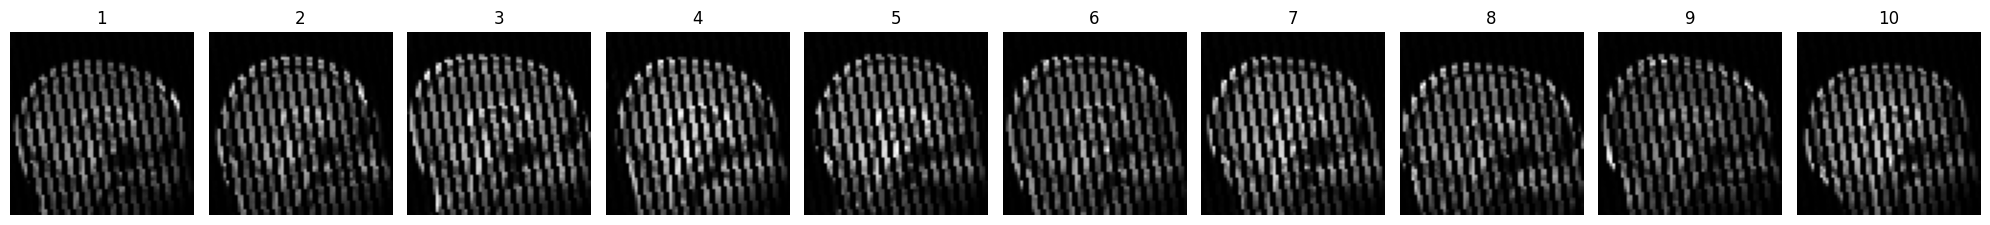

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# load data
data = np.load('/content/drive/MyDrive/dl-module-coursework-1-esemsc-f8af2eba/test_set.npy')

# create figure
fig, axes = plt.subplots(1, 10, figsize=(20, 5))

for i in range(10):
    image = data[i].squeeze()  # delete channel dimension in (1, 64, 64) 
    axes[i].imshow(image, cmap='gray')  # show gray image
    axes[i].axis('off')  # delete axis
    axes[i].set_title(f"{i+1}")  # set up title

# adjust the layout
plt.tight_layout()
plt.show()


To construct the training pipeline, I first converted the images generated in Question 1 into a PyTorch TensorDataset. These clean brain images serve as the ground-truth targets. Since the goal of the task is image reconstruction, I applied an appropriate corruption process to each generated image so that the corrupted version resembles the images provided in the test set. In this way, each training sample consists of a pair: the corrupted image as the input and the corresponding clean image as the label.

After constructing the paired dataset, I wrapped it in a PyTorch DataLoader to enable efficient mini-batch training, ensuring proper batching and shuffling during optimisation.

For the test dataset, I loaded the corrupted images from test_set.npy, converted them into tensors, and created a separate TensorDataset and DataLoader. Since no ground-truth labels are available for the test set, the dataset only provides the corrupted input images.

Finally, I visualised ten samples from the training dataset, displaying both the corrupted inputs and their corresponding clean labels to verify that the pairing and corruption process were implemented correctly. I also displayed ten samples from the test dataset to examine their characteristics and confirm consistency with the corruption strategy used for training.

## load data

In [108]:

generated_sample = np.load('/content/drive/MyDrive/generated_sample.npy')
test_data = np.load('/content/drive/MyDrive/dl-module-coursework-1-esemsc-f8af2eba/test_set.npy')

## Corruped images and corresponding original images

In [111]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

class BrainImagesDataset(Dataset):
    def __init__(self, generated_sample, split="train", stripe_width=5, angle=15, opacity=0.5, transform=None):
        if isinstance(generated_sample, np.ndarray):
          generated_sample = torch.from_numpy(generated_sample).float()
        self.split = split
        self.transform = transform
        self.stripe_width = stripe_width
        self.angle = angle
        self.opacity = opacity
        self.generated_sample = generated_sample.view(-1, 1, 64, 64)  # Add channel dimension properly

    def _get_mask(self, img_shape):
      c, h, w = img_shape
      mask = torch.ones((c, h, w))  # Start with a fully visible image

      stripe_width = 4  # Adjust width of each stripe to match the pattern in the example
      space_between_stripes = 2  # Space between stripes could be adjusted as needed
      opacity = 0  # Ensure full transparency for the stripes

      # Calculate horizontal offsets more accurately
      offset_per_row = 1  # Adjust this to change how the stripes align from row to row

      for row in range(h):
          offset = (row * offset_per_row) % (stripe_width + space_between_stripes)
          for col in range(offset, w, stripe_width + space_between_stripes):
              start_col = col
              end_col = min(col + stripe_width, w)
              mask[:, row, start_col:end_col] *= opacity  # Apply the transparency

      # Adjust tilt angle
      tilt_angle = -30  # Less steep angle

      # Rotate the mask by the tilt angle
      if tilt_angle != 0:
          from scipy.ndimage import rotate
          mask = torch.tensor(rotate(mask.numpy(), angle=tilt_angle, axes=(1, 2), reshape=False, mode='nearest'), dtype=torch.float32)

      return mask

    def __getitem__(self, idx):
        img = self.generated_sample[idx]

        if self.transform:
            img = self.transform(img)

        if self.split == "train":
            # label = self.labels[idx]
            mask = self._get_mask(img.shape)
            corrupted_img = img * mask
            return corrupted_img,img
        else:
            return img,torch.zeros(1)  # No labels in test set

    def __len__(self):
        return len(self.generated_sample)

    def __str__(self):
        class_string = f"{self.__class__.__name__}\n\tLength: {self.__len__()}"
        for key, value in self.__dict__.items():
            if key != "data":
                class_string += f"\n\t{key}: {value}"
        return class_string


# Transformations (if any)
transform = transforms.Compose([
    # transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Create datasets
train_dataset = BrainImagesDataset(generated_sample, split="train")
test_dataset = BrainImagesDataset(test_data, split="test")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)



Displaying Training Set Images:


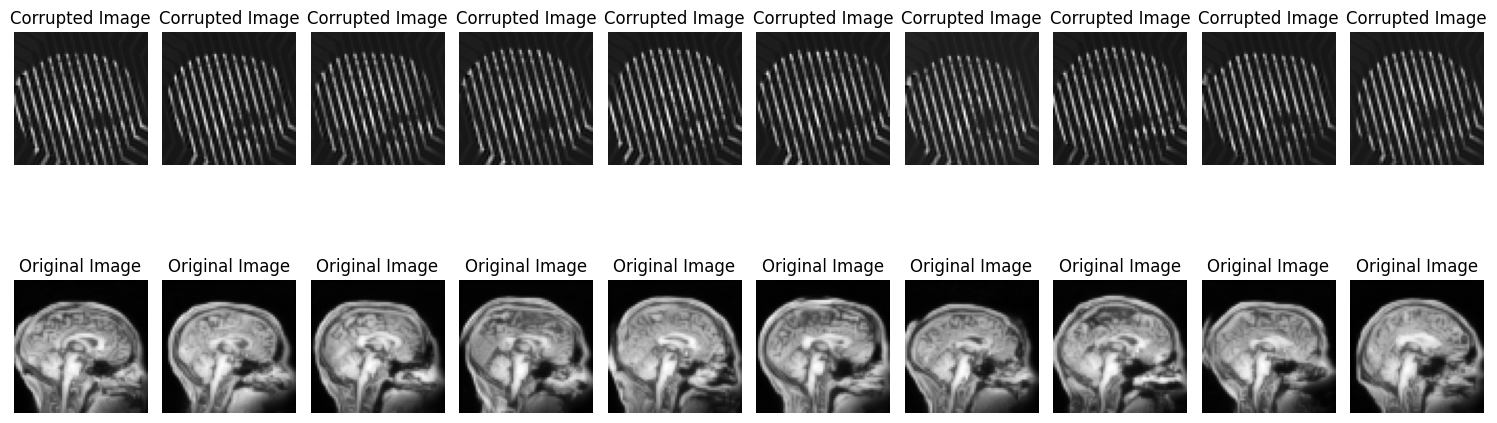

Displaying Test Set Images:


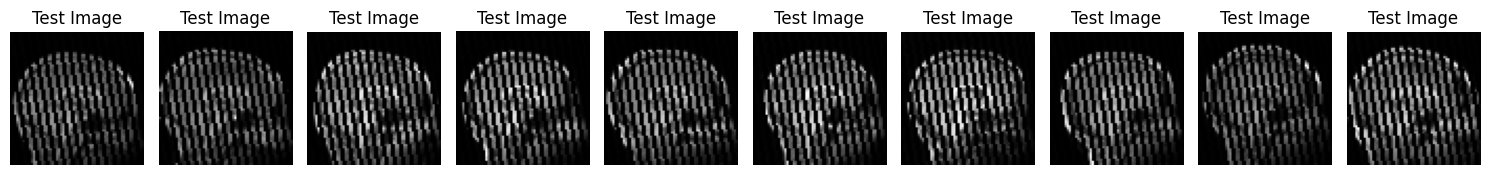

In [102]:
import matplotlib.pyplot as plt

def show_images(loader, num_images=10, dataset_type="train"):
    if dataset_type == "train":
        # For the training data, display corrupted and original images.
        fig, axs = plt.subplots(2, num_images, figsize=(15, 6))  # 2 rows for corrupted and original
        for idx, (corrupted, original) in enumerate(loader):
            if idx >= num_images:
                break
            axs[0, idx].imshow(corrupted[0, 0].cpu().numpy(), cmap='gray')
            axs[0, idx].axis('off')
            axs[0, idx].set_title('Corrupted Image')

            axs[1, idx].imshow(original[0, 0].cpu().numpy(), cmap='gray')
            axs[1, idx].axis('off')
            axs[1, idx].set_title('Original Image')
    elif dataset_type == "test":
        # For the test data, display only the corrupted images as no original is available.
        fig, axs = plt.subplots(1, num_images, figsize=(15, 3))  # 1 row for test images
        for idx, (corrupted, _) in enumerate(loader):
            if idx >= num_images:
                break
            axs[idx].imshow(corrupted[0, 0].cpu().numpy(), cmap='gray')
            axs[idx].axis('off')
            axs[idx].set_title('Test Image')

    plt.tight_layout()
    plt.show()

# Assuming train_loader and test_loader are properly defined and initialized
print("Displaying Training Set Images:")
show_images(train_loader, num_images=10, dataset_type="train")
print("Displaying Test Set Images:")
show_images(test_loader, num_images=10, dataset_type="test")


In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using the dataset constructed in Question 2, I designed and trained a neural network architecture to reconstruct the missing image lines in the corrupted test dataset. Since pre-trained networks were not permitted, I developed and trained the model entirely from scratch.

To address the reconstruction task, I selected an architecture that is well suited for image-to-image learning. The model takes corrupted 64×64 brain images as input and learns to predict the corresponding clean images by minimising a reconstruction loss between the output and the ground-truth targets. During training, I carefully tuned key hyperparameters such as learning rate, batch size, and number of epochs to ensure stable convergence and good generalisation performance.

After training, I applied the model to the corrupted images in the test set and generated reconstructed outputs with the missing lines filled in. I displayed ten examples of these reconstructed test images to visually assess the quality of the recovery.

Finally, I saved all reconstructed test images into a NumPy file named test_set_nogaps.npy. The images were stored in the exact same order as in the original test_set.npy file and maintained the required resolution of 64×64 pixels to ensure correct evaluation. Care was taken to preserve ordering consistency so that each reconstructed image corresponds precisely to its original corrupted counterpart.

In addition to presenting the results, I have included a detailed explanation of the chosen network architecture, along with the design decisions and hyperparameters that were most important for achieving good reconstruction performance. Where external references or tools (including online resources and chatGPT) were consulted, they have been clearly acknowledged.

<br>

---

<br>

# **VAEs**

100%|██████████| 41/41 [00:22<00:00,  1.84it/s]


Epoch 1, Loss: 1.0716341964945924


100%|██████████| 41/41 [00:21<00:00,  1.87it/s]


Epoch 2, Loss: 0.011308016641656073


100%|██████████| 41/41 [00:21<00:00,  1.87it/s]


...

Epoch 8, Loss: 0.007141621953739625


100%|██████████| 41/41 [00:22<00:00,  1.86it/s]


Epoch 9, Loss: 0.007000782470241553


100%|██████████| 41/41 [00:21<00:00,  1.87it/s]


Epoch 10, Loss: 0.0071662154684706434


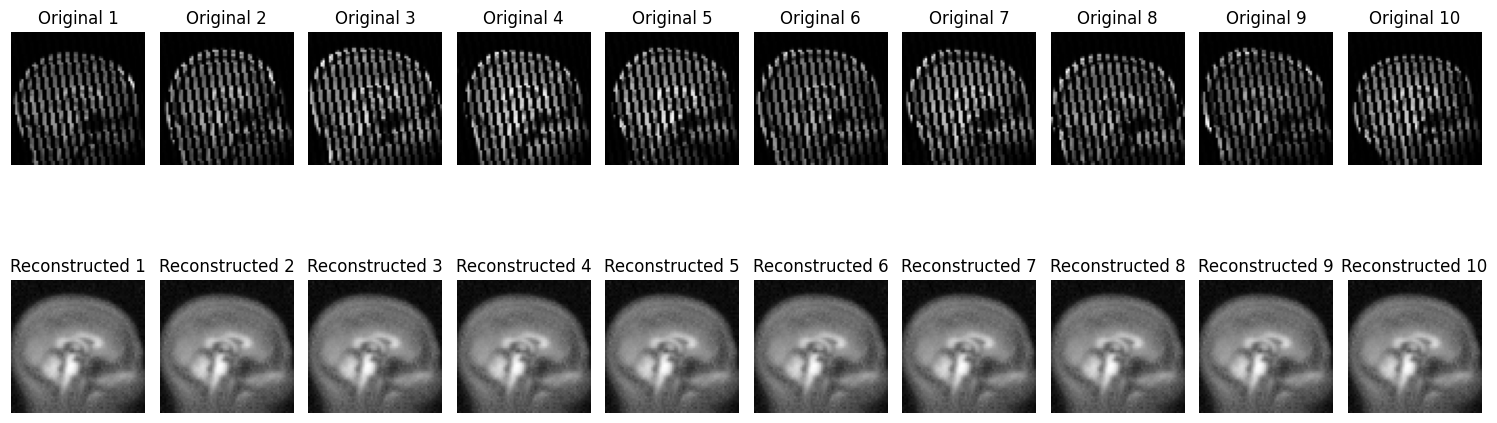

In [97]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from tqdm import tqdm

# Define the VAE components
class VAE(nn.Module):
    def __init__(self, latent_dims):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64*64, 400),
            nn.ReLU(),
            nn.Linear(400, latent_dims*2)  # Output both mu and sigma
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 400),
            nn.ReLU(),
            nn.Linear(400, 64*64),
            nn.Sigmoid()  # Ensure output is between 0 and 1
        )

    def forward(self, x):
        x = x.view(-1, 64*64)
        latent_params = self.encoder(x)
        mu = latent_params[:, :latent_dims]
        sigma = torch.exp(latent_params[:, latent_dims:])  # Sigma must be positive
        z = mu + sigma * torch.randn_like(sigma)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 64, 64)
        kl_div = -0.5 * torch.sum(1 + torch.log(sigma**2) - mu**2 - sigma**2)
        return x_recon, kl_div

    def reconstruct(self, x):
        with torch.no_grad():
            x = x.view(-1, 64*64)
            latent_params = self.encoder(x)
            mu = latent_params[:, :latent_dims]
            z = mu  # Use the mean for reconstruction to avoid randomness
            x_recon = self.decoder(z)
            return x_recon.view(-1, 1, 64, 64)

# Load data and prepare DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Example normalization, adjust as needed
])

# # Dummy dataset, replace with your actual dataset
# dataset = datasets.MNIST(root='.', train=True, transform=transform, download=True)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize model, optimizer, and set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dims = 10
vae = VAE(latent_dims).to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Training loop
def train_vae(vae, data_loader, epochs=10):
    vae.train()
    for epoch in range(epochs):
        total_loss = 0
        for corrupted_images, original in tqdm(data_loader):
            corrupted_images = corrupted_images.to(device)
            original = original.to(device)
            optimizer.zero_grad()
            recon_images, kl_div = vae(corrupted_images)
            loss = ((original - recon_images)**2).mean() + kl_div  # MSE loss + KL divergence
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(data_loader)}')

train_vae(vae, train_loader, epochs=10)

# Generate and save reconstructed images
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
reconstructed = vae.reconstruct(test_images)
reconstructed = reconstructed.cpu().numpy()

# Save images as a numpy file
np.save('test_set_nogaps.npy', reconstructed)

# Assuming `corrupted_images` and `reconstructed` are lists or tensors of images
# Ensure these variables are correctly populated with the corresponding image data prior to using this snippet

# Display some of the reconstructed images alongside the corrupted images for comparison
def plot_reconstructions(original_images, reconstructed_images, num_images=10):
    """
    Plot a comparison of original and reconstructed images.

    Args:
    original_images (Tensor or array): The original images from the dataset.
    reconstructed_images (Tensor or array): The images reconstructed by the VAE.
    num_images (int): Number of images to display.
    """
    # Check if the tensors are on GPU and move them to CPU if necessary
    if torch.is_tensor(original_images) and original_images.is_cuda:
        original_images = original_images.cpu().numpy()
    elif not isinstance(original_images, np.ndarray):
        original_images = original_images.numpy()  # Convert to numpy if it's not already

    if torch.is_tensor(reconstructed_images) and reconstructed_images.is_cuda:
        reconstructed_images = reconstructed_images.cpu().numpy()
    elif not isinstance(reconstructed_images, np.ndarray):
        reconstructed_images = reconstructed_images.numpy()  # Convert to numpy if it's not already

    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))  # 2 rows and 'num_images' columns
    for i in range(num_images):
        # Original Images
        ax = axes[0, i]
        ax.imshow(original_images[i].squeeze(), cmap='gray')
        ax.set_title("Original {}".format(i + 1))
        ax.axis('off')

        # Reconstructed Images
        ax = axes[1, i]
        ax.imshow(reconstructed_images[i].squeeze(), cmap='gray')
        ax.set_title("Reconstructed {}".format(i + 1))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Assuming you retrieve these from somewhere after processing
# These should be tensors if coming directly from PyTorch model output
original_images = test_images  # PyTorch Tensor
reconstructed = vae.reconstruct(test_images)  # This should be a PyTorch Tensor

# Use the function to plot
plot_reconstructions(original_images, reconstructed, num_images=10)



Seems like model collapes.

In [ ]:
print(os.getcwd())

# **U-net**

  1%|          | 2/320 [00:00<00:55,  5.73it/s]

Epoch [1/10], Loss: 0.1740
Epoch [1/10], Loss: 0.1655


  1%|▏         | 4/320 [00:00<00:55,  5.73it/s]

Epoch [1/10], Loss: 0.1686
Epoch [1/10], Loss: 0.1510


  2%|▏         | 6/320 [00:01<00:54,  5.74it/s]

...

Epoch [10/10], Loss: 0.0023
Epoch [10/10], Loss: 0.0017


100%|█████████▉| 319/320 [00:56<00:00,  5.63it/s]

Epoch [10/10], Loss: 0.0019
Epoch [10/10], Loss: 0.0018


100%|██████████| 320/320 [00:57<00:00,  5.61it/s]


Epoch [10/10], Loss: 0.0019


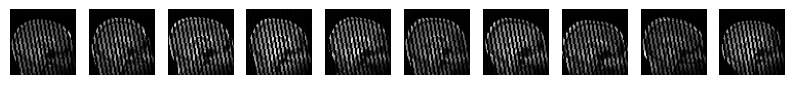

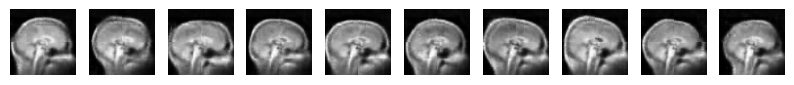

In [105]:

import torch
from torch import nn, optim
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define a simple U-net model
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        # Encoder part of the U-net: two convolutional layers with ReLU and max pooling
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # First conv layer: 1 input channel, 16 output channels
            nn.BatchNorm2d(16),
            nn.ReLU(),  # Activation function to introduce non-linearity
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling to reduce spatial dimensions
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(32),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(64),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(128),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling layer
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # Second conv layer: 16 input channels, 32 output channels
            nn.BatchNorm2d(256),
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2)  # Pooling layer
        )
        # Decoder part of the U-net: transpose convolutions to upscale the feature maps
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # Upscale and increase feature map detail
            nn.ReLU(),  # Activation function
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),  # Restore to original dimensions
            nn.Sigmoid()  # Sigmoid to output probabilities (ideal for binary segmentation)
        )

    def forward(self, x):
        x = self.encoder(x)  # Pass input through the encoder
        x = self.decoder(x)  # Decode the encoded features
        return x

# Initialize model, optimizer, loss function, and specify device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.MSELoss()  # Loss function for measuring reconstruction error
optimizer = optim.Adam(model.parameters(), lr=0.002)  # Optimizer for training

# Load and prepare data, applying necessary transformations
transform = ToTensor()  # Transform to convert images to torch.Tensor
# dataset = datasets.MNIST(root='.', download=True, transform=transform)  # MNIST dataset
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)  # DataLoader to batch and shuffle data


# Training loop
n_epoch = 10
model.train()  # Set model to training mode
for epoch in range(n_epoch):

    for corrupted_images, original in tqdm(train_loader):
        corrupted_images = corrupted_images.to(device)  # Move images to device
        original = original.to(device)  # Move labels to device

        optimizer.zero_grad()  # Clear gradients for this training step

        outputs = model(corrupted_images)  # Forward pass: compute predicted outputs by passing inputs to the model

        loss = criterion(outputs, original)  # Compute loss: how far are we from the target?


        loss.backward()  # Backward pass: compute gradient of the loss with respect to model parameters

        optimizer.step()  # Perform a single optimization step (parameter update)



        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {loss.item():.4f}')  # Log loss



# Function to display images
def show_images(images, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))  # Setup plot
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i].detach().cpu().numpy().squeeze(), cmap='gray')  # Display image
        ax.axis('off')  # Hide axes

    plt.show()  # Show the plot

# Display some original and reconstructed images to verify reconstruction quality
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Context-manager that disables gradient calculation
    images, _ = next(iter(train_loader))
    images=images.to(device)  # Load a batch of images
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    reconstructed_images = model(images)  # Reconstruct images using the model
    show_images(test_images, num_images=10)  # Display original images
    show_images(reconstructed_images, num_images=10)  # Display reconstructed images

    # Save images as a numpy file
np.save('test_set_nogaps.npy', reconstructed_images.cpu().numpy())

In [90]:
pip install livelossplot

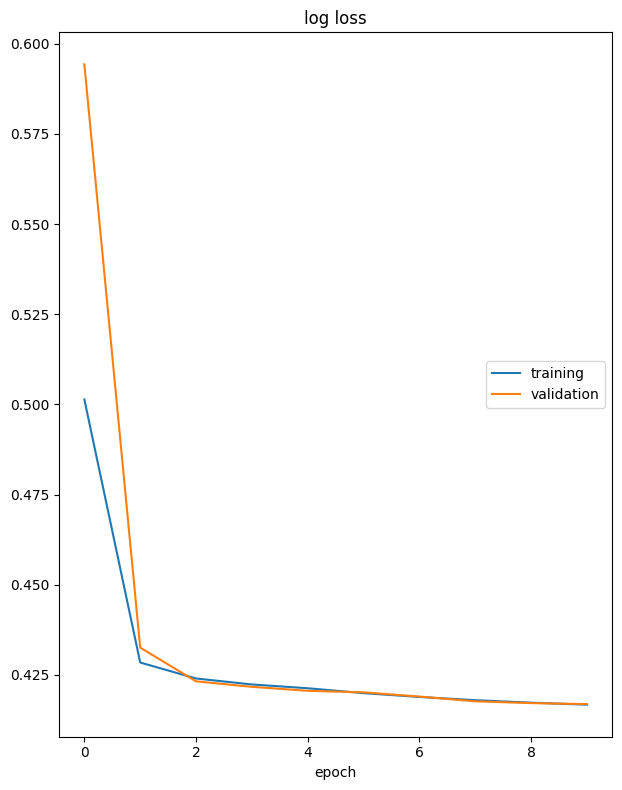

log loss
	training         	 (min:    0.417, max:    0.501, cur:    0.417)
	validation       	 (min:    0.417, max:    0.594, cur:    0.417)
Model saved to ./unet_segmentation_model.pt


In [113]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
from livelossplot import PlotLosses
import numpy as np

# Define a simple U-Net model
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset and DataLoader
transform = transforms.Compose([transforms.ToTensor()])
# dataset = datasets.MNIST(root='.', train=True, download=True, transform=transform)

# # Create datasets
# train_dataset = BrainImagesDataset(generated_sample, split="train")
# test_dataset = BrainImagesDataset(test_data, split="test")

# # Create DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# Split dataset into training and validation sets
train_val_split_ratio = 0.8
train_size = int(train_val_split_ratio * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Initialize model, optimizer, and loss function
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

# Training and validation
n_epochs = 10
liveloss = PlotLosses()

for epoch in range(n_epochs):
    logs = {}

    # Training phase
    model.train()
    train_loss = 0
    for corrupted_images, original in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
        corrupted_images, original = corrupted_images.to(device), original.to(device)

        optimizer.zero_grad()
        outputs = model(corrupted_images)
        loss = criterion(outputs, original)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    logs['log loss'] = train_loss

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for corrupted_images, original in val_loader:
            corrupted_images, original = corrupted_images.to(device), original.to(device)
            outputs = model(corrupted_images)
            loss = criterion(outputs, original)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    logs['val_log loss'] = val_loss

    # Update live loss plot
    liveloss.update(logs)
    liveloss.draw()

# Save the trained model
model_save_name = 'unet_segmentation_model.pt'
path = f"./{model_save_name}"
torch.save(model.state_dict(), path)
print(f"Model saved to {path}")

# Display reconstructed images
model.eval()
with torch.no_grad():
    images, _ = next(iter(val_loader))
    images = images.to(device)
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    reconstructed_images = model(images)

#     def show_images(images, num_images=4):
#         fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
#         for i in range(num_images):
#             ax = axes[i]
#             ax.imshow(images[i].detach().cpu().numpy().squeeze(), cmap='gray')
#             ax.axis('off')
#         plt.show()

#     show_images(test_images, num_images=10)
#     show_images(reconstructed_images, num_images=10)

# np.save('test_set_nogaps.npy', reconstructed_images.cpu().numpy())


Here is my log loss function, showing a better results in validation set. The model converges at about 1 epoch,and final loss close to 0.417.

# **GANs**

In [88]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import numpy as np

# Define a simple convolutional GAN for image completion
class Generator(nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(g_input_dim, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, g_output_dim, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, d_input_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(d_input_dim, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

# Build model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G = Generator(1, 1).to(device)  # Assuming grayscale images
D = Discriminator(1).to(device)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training and testing logic integration
for epoch in range(20):  # Number of epochs
    for real_images, _ in train_loader:  # Assuming images are loaded with shape (batch_size, 1, 64, 64)
        # Train Discriminator
        # ...

        # Train Generator
        # ...

# Saving model predictions on test set
test_images = torch.cat([G(real_images.to(device)) for real_images, _ in test_loader], dim=0).cpu().numpy()
np.save('test_set_nogaps.npy', test_images)

# Show some example outputs
show_images(test_images, num_images=10)


IndentationError: expected an indented block after 'for' statement on line 49 (<ipython-input-88-9dfd5d718645>, line 57)

Reasons to Use VAE：


The purpose of VAEs is to produce fresh data points that resemble the training set. Because of this, they can be used for tasks including data augmentation, style transfer, and image production.

VAEs provide interpolation between data points by mapping input data to a continuous and structured latent space. For tasks like transforming photos or identifying hidden relationships in data, this is helpful.
Frequentized Education:


In VAE loss, the KL divergence term guarantees that the latent space has a typical normal distribution. This regularization strengthens the model's robustness and enhances generalization.


By learning the latent space's mean and variance, VAEs offer a probabilistic representation. This aids in estimating uncertainty, which is useful for evaluating model reliability and making decisions.


Reasons to use U-Net:

U-Net expertise in medical image segmentation, it combines low-level feature maps from the encoder with high-level feature maps from the decoder through skip connections. This allows for precise localization while preserving contextual information, which is essential for tasks like medical image segmentation.

They are suitable for only a few features in the data (e.g. greyscale or single-channel images), but the segmentation is more complex in shape or structure.
Reason: U-Net can still restore complex shapes with its powerful decoding ability on simple feature data.

Despite its ability to produce highly detailed outputs, U-Net is computationally efficient compared to other complex architectures, making it suitable for real-time applications when adapted.
In U-Net, I add more convolutional layers,batch normalisation in neuro network, add define log transformattion in loss function criterion.
